# Diabetes Prediction Dataset

## Step 1: Data Import and Exploratory Data Analysis

In [4]:
#Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Dataset source: 
dataset_source = 'https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset'
print(f'Our dataset source: {dataset_source}')

#Load the diabetes prediction dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')

#Dataset sample
print('\n')
df.head(10)

Our dataset source: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset




,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [5]:
#Printing record & column count
records, columns = df.shape
print(f'Record count: {records}')
print(f'Column count: {columns}')

Record count: 100000
Column count: 9


In [6]:
#Checking number of null values and data types by column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [7]:
#Looking at basic statistical measures of the dataset
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
# Assuming you have a DataFrame A, you can create DataFrame B containing duplicates as follows:
def get_duplicate_records(df):
    # Find duplicate rows based on all columns
    duplicate_mask = df.duplicated(keep=False)

    # Filter DataFrame A to get only the duplicate rows
    df_duplicates = df[duplicate_mask]

    # If you want to reset the index of the new DataFrame B:
    df_duplicates = df_duplicates.reset_index(drop=True)

    return df_duplicates

df_b = get_duplicate_records(df)

df_b.to_csv('dupes.csv',index=False)

In [8]:
#Checking for duplicate records - which records were duplicates? Are there any records where they're all the same, besides the diabetes? Focus on greater than 5.7 a1c
dupes = df.duplicated().sum()
print(f'There are {dupes} duplicate records')

#Deleting duplicate records -- KEEP DUPES
#df = df.drop_duplicates()

There are 3854 duplicate records


In [9]:
#Filtering to >= 5.7 HbA1c levels
df_test = df[df['HbA1c_level'] >= 5.7]
print(df_test.shape)

#High A1c but no diabetes
df_no_diabetes = df[(df['HbA1c_level'] >= 5.7) & (df['diabetes'] == 0)]
print(df_no_diabetes.shape)

(62143, 9)
(53643, 9)


### Evaluating legitimacy of column values (all records vs. high A1c only)

#### Age

[ 0.08  0.16  0.24  0.32  0.4   0.48  0.56  0.64  0.72  0.8   0.88  1.
  1.08  1.16  1.24  1.32  1.4   1.48  1.56  1.64  1.72  1.8   1.88  2.
  3.    4.    5.    6.    7.    8.    9.   10.   11.   12.   13.   14.
 15.   16.   17.   18.   19.   20.   21.   22.   23.   24.   25.   26.
 27.   28.   29.   30.   31.   32.   33.   34.   35.   36.   37.   38.
 39.   40.   41.   42.   43.   44.   45.   46.   47.   48.   49.   50.
 51.   52.   53.   54.   55.   56.   57.   58.   59.   60.   61.   62.
 63.   64.   65.   66.   67.   68.   69.   70.   71.   72.   73.   74.
 75.   76.   77.   78.   79.   80.  ]

Takeaway: No issues here. Assume lower numbers with decimals correspond to infants. Age is generally evenly distributed.


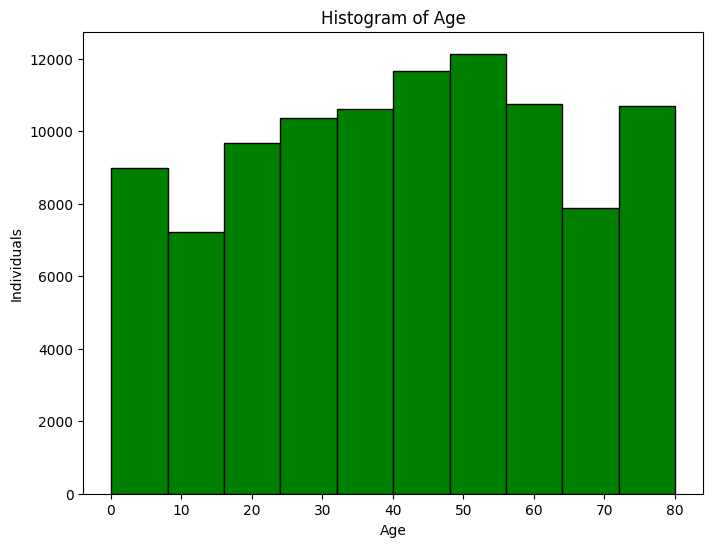

In [10]:
#Display unique values
sorted_unique_values_age = df['age'].sort_values().unique()
print(sorted_unique_values_age)

#Develop histogram to show distribution of values
plt.figure(figsize=(8, 6))
plt.hist(df['age'], bins=10, edgecolor='black', color='green')
plt.xlabel('Age')
plt.ylabel('Individuals')
plt.title('Histogram of Age')

#Conclusion
print('\nTakeaway: No issues here. Assume lower numbers with decimals correspond to infants. Age is generally evenly distributed.')

[ 0.08  0.16  0.24  0.32  0.4   0.48  0.56  0.64  0.72  0.8   0.88  1.
  1.08  1.16  1.24  1.32  1.4   1.48  1.56  1.64  1.72  1.8   1.88  2.
  3.    4.    5.    6.    7.    8.    9.   10.   11.   12.   13.   14.
 15.   16.   17.   18.   19.   20.   21.   22.   23.   24.   25.   26.
 27.   28.   29.   30.   31.   32.   33.   34.   35.   36.   37.   38.
 39.   40.   41.   42.   43.   44.   45.   46.   47.   48.   49.   50.
 51.   52.   53.   54.   55.   56.   57.   58.   59.   60.   61.   62.
 63.   64.   65.   66.   67.   68.   69.   70.   71.   72.   73.   74.
 75.   76.   77.   78.   79.   80.  ]

Takeaway: No issues here. Assume lower numbers with decimals correspond to infants. Age is generally evenly distributed.


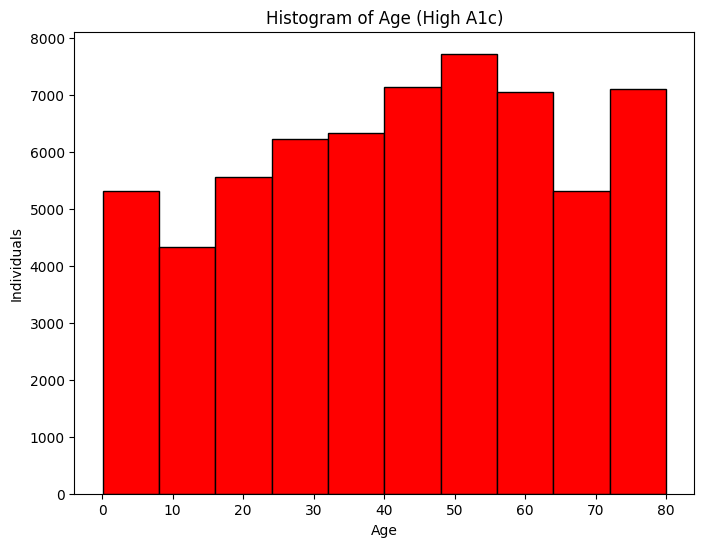

In [11]:
#Display unique values (high A1c only)
sorted_unique_values_age = df_test['age'].sort_values().unique()
print(sorted_unique_values_age)

#Develop histogram to show distribution of values
plt.figure(figsize=(8, 6))
plt.hist(df_test['age'], bins=10, edgecolor='black', color='red')
plt.xlabel('Age')
plt.ylabel('Individuals')
plt.title('Histogram of Age (High A1c)')

#Conclusion
print('\nTakeaway: No issues here. Assume lower numbers with decimals correspond to infants. Age is generally evenly distributed.')

[ 0.08  0.16  0.24  0.32  0.4   0.48  0.56  0.64  0.72  0.8   0.88  1.
  1.08  1.16  1.24  1.32  1.4   1.48  1.56  1.64  1.72  1.8   1.88  2.
  3.    4.    5.    6.    7.    8.    9.   10.   11.   12.   13.   14.
 15.   16.   17.   18.   19.   20.   21.   22.   23.   24.   25.   26.
 27.   28.   29.   30.   31.   32.   33.   34.   35.   36.   37.   38.
 39.   40.   41.   42.   43.   44.   45.   46.   47.   48.   49.   50.
 51.   52.   53.   54.   55.   56.   57.   58.   59.   60.   61.   62.
 63.   64.   65.   66.   67.   68.   69.   70.   71.   72.   73.   74.
 75.   76.   77.   78.   79.   80.  ]

Takeaway: No issues here. Assume lower numbers with decimals correspond to infants. Age is generally evenly distributed.


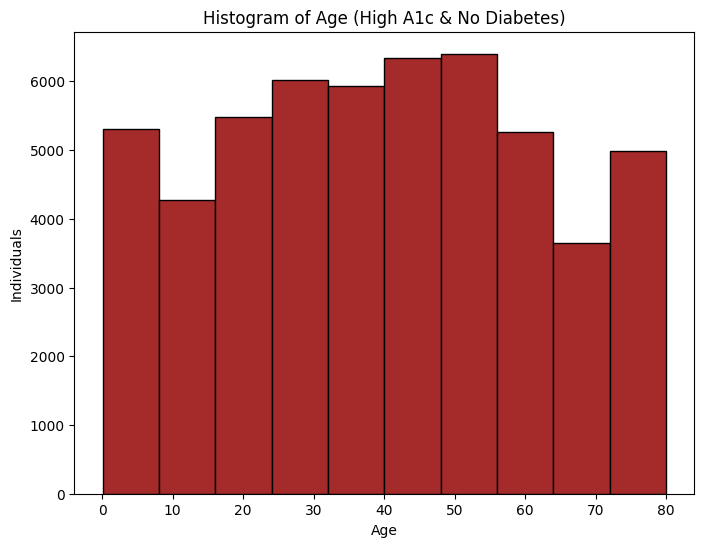

In [12]:
#Display unique values (high A1c and no diabetes only)
sorted_unique_values_age = df_no_diabetes['age'].sort_values().unique()
print(sorted_unique_values_age)

#Develop histogram to show distribution of values
plt.figure(figsize=(8, 6))
plt.hist(df_no_diabetes['age'], bins=10, edgecolor='black', color='brown')
plt.xlabel('Age')
plt.ylabel('Individuals')
plt.title('Histogram of Age (High A1c & No Diabetes)')

#Conclusion
print('\nTakeaway: No issues here. Assume lower numbers with decimals correspond to infants. Age is generally evenly distributed.')

#### Hypertension

[0 1]


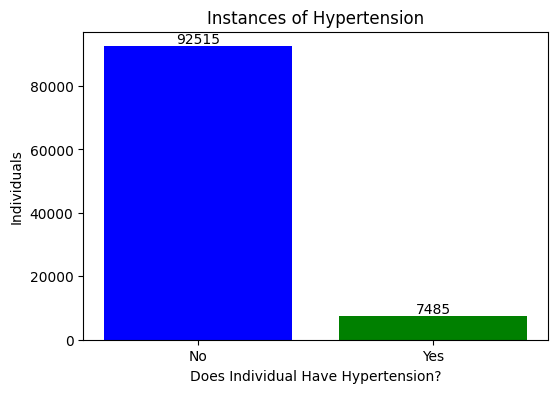


Takeaway: No issues here. Hypertension is a binary field. Per the Kaggle dataset, 0 indicates no hypertension, while 1 indicates hypertension. There are significantly more people without hypertension than those who have it.


In [13]:
#Display unique values
sorted_unique_values_hypertension = df['hypertension'].sort_values().unique()
print(sorted_unique_values_hypertension)

#Develop bar chart to show distribution of values
value_counts_hypertension = df['hypertension'].value_counts()
plt.figure(figsize=(6, 4))
bars_hypertension = plt.bar(value_counts_hypertension.index, value_counts_hypertension.values, color=['blue', 'green'])
for bar in bars_hypertension:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Hypertension?')
plt.ylabel('Individuals')
plt.title('Instances of Hypertension')
plt.show()

#Conclusion
print('\nTakeaway: No issues here. Hypertension is a binary field. Per the Kaggle dataset, 0 indicates no hypertension, while 1 indicates hypertension. There are significantly more people without hypertension than those who have it.')

[0 1]


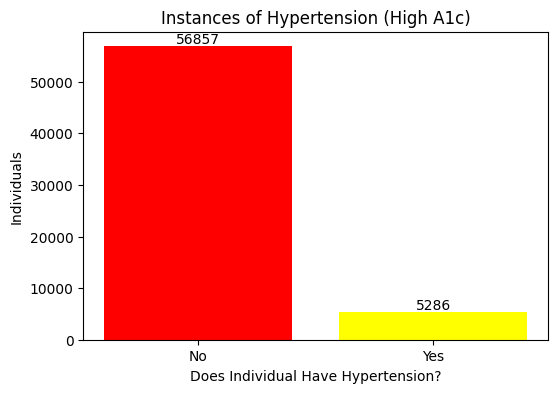


Takeaway: No issues here. Hypertension is a binary field. Per the Kaggle dataset, 0 indicates no hypertension, while 1 indicates hypertension. There are significantly more people without hypertension than those who have it.


In [14]:
#Display unique values (high A1c only)
sorted_unique_values_hypertension = df_test['hypertension'].sort_values().unique()
print(sorted_unique_values_hypertension)

#Develop bar chart to show distribution of values
value_counts_hypertension = df_test['hypertension'].value_counts()
plt.figure(figsize=(6, 4))
bars_hypertension = plt.bar(value_counts_hypertension.index, value_counts_hypertension.values, color=['red', 'yellow'])
for bar in bars_hypertension:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Hypertension?')
plt.ylabel('Individuals')
plt.title('Instances of Hypertension (High A1c)')
plt.show()

#Conclusion
print('\nTakeaway: No issues here. Hypertension is a binary field. Per the Kaggle dataset, 0 indicates no hypertension, while 1 indicates hypertension. There are significantly more people without hypertension than those who have it.')

[0 1]


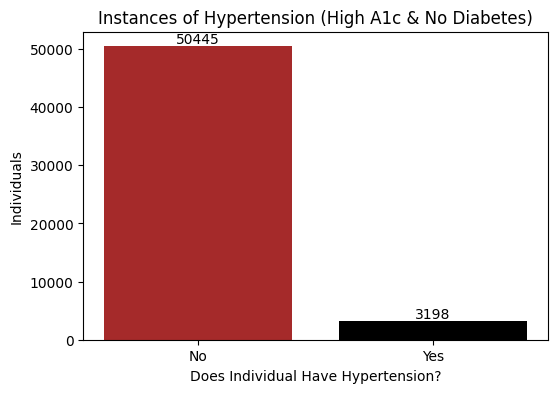


Takeaway: No issues here. Hypertension is a binary field. Per the Kaggle dataset, 0 indicates no hypertension, while 1 indicates hypertension. There are significantly more people without hypertension than those who have it.


In [15]:
#Display unique values (high A1c only and no diabetes only)
sorted_unique_values_hypertension = df_no_diabetes['hypertension'].sort_values().unique()
print(sorted_unique_values_hypertension)

#Develop bar chart to show distribution of values
value_counts_hypertension = df_no_diabetes['hypertension'].value_counts()
plt.figure(figsize=(6, 4))
bars_hypertension = plt.bar(value_counts_hypertension.index, value_counts_hypertension.values, color=['brown', 'black'])
for bar in bars_hypertension:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Hypertension?')
plt.ylabel('Individuals')
plt.title('Instances of Hypertension (High A1c & No Diabetes)')
plt.show()

#Conclusion
print('\nTakeaway: No issues here. Hypertension is a binary field. Per the Kaggle dataset, 0 indicates no hypertension, while 1 indicates hypertension. There are significantly more people without hypertension than those who have it.')

#### Heart Disease

[0 1]


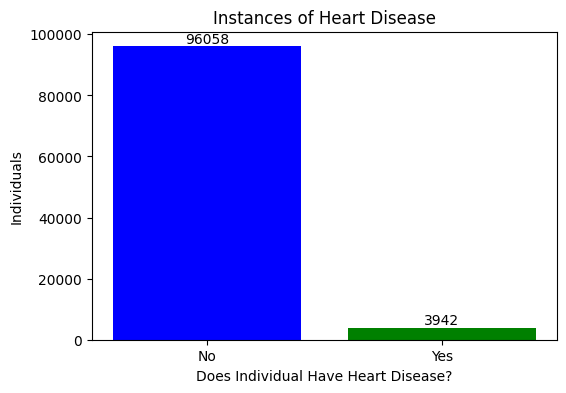


Takeaway: No issues here. Heart disease is a binary field. Per the Kaggle dataset, 0 indicates no heart disease, while 1 indicates heart disease. There are significantly more people without heart disease than those who have it.


In [16]:
#Display unique values
sorted_unique_values_heart_disease = df['heart_disease'].sort_values().unique()
print(sorted_unique_values_heart_disease)

#Develop bar chart to show distribution of values
value_counts_heart_disease = df['heart_disease'].value_counts()
plt.figure(figsize=(6, 4))
bars_heart_disease = plt.bar(value_counts_heart_disease.index, value_counts_heart_disease.values, color=['blue', 'green'])
for bar in bars_heart_disease:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Heart Disease?')
plt.ylabel('Individuals')
plt.title('Instances of Heart Disease')
plt.show()

#Conclusion
print('\nTakeaway: No issues here. Heart disease is a binary field. Per the Kaggle dataset, 0 indicates no heart disease, while 1 indicates heart disease. There are significantly more people without heart disease than those who have it.')

[0 1]


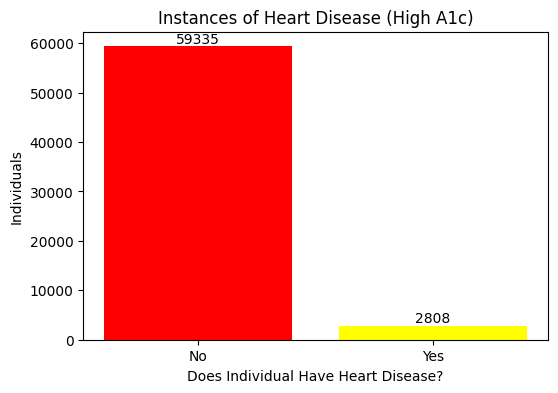


Takeaway: No issues here. Heart disease is a binary field. Per the Kaggle dataset, 0 indicates no heart disease, while 1 indicates heart disease. There are significantly more people without heart disease than those who have it.


In [17]:
#Display unique values (high A1c only)
sorted_unique_values_heart_disease = df_test['heart_disease'].sort_values().unique()
print(sorted_unique_values_heart_disease)

#Develop bar chart to show distribution of values
value_counts_heart_disease = df_test['heart_disease'].value_counts()
plt.figure(figsize=(6, 4))
bars_heart_disease = plt.bar(value_counts_heart_disease.index, value_counts_heart_disease.values, color=['red', 'yellow'])
for bar in bars_heart_disease:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Heart Disease?')
plt.ylabel('Individuals')
plt.title('Instances of Heart Disease (High A1c)')
plt.show()

#Conclusion
print('\nTakeaway: No issues here. Heart disease is a binary field. Per the Kaggle dataset, 0 indicates no heart disease, while 1 indicates heart disease. There are significantly more people without heart disease than those who have it.')

[0 1]


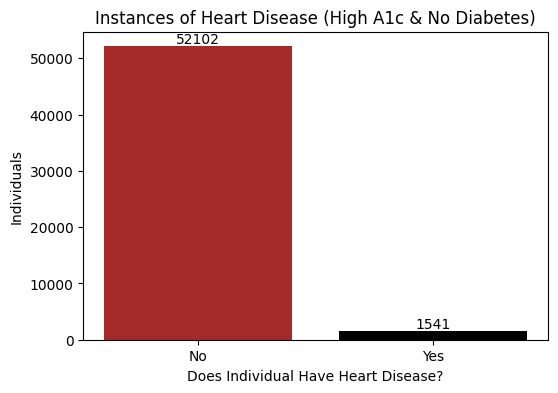


Takeaway: No issues here. Heart disease is a binary field. Per the Kaggle dataset, 0 indicates no heart disease, while 1 indicates heart disease. There are significantly more people without heart disease than those who have it.


In [18]:
#Display unique values (high A1c and no diabetes only)
sorted_unique_values_heart_disease = df_no_diabetes['heart_disease'].sort_values().unique()
print(sorted_unique_values_heart_disease)

#Develop bar chart to show distribution of values
value_counts_heart_disease = df_no_diabetes['heart_disease'].value_counts()
plt.figure(figsize=(6, 4))
bars_heart_disease = plt.bar(value_counts_heart_disease.index, value_counts_heart_disease.values, color=['brown', 'black'])
for bar in bars_heart_disease:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Heart Disease?')
plt.ylabel('Individuals')
plt.title('Instances of Heart Disease (High A1c & No Diabetes)')
plt.show()

#Conclusion
print('\nTakeaway: No issues here. Heart disease is a binary field. Per the Kaggle dataset, 0 indicates no heart disease, while 1 indicates heart disease. There are significantly more people without heart disease than those who have it.')

#### BMI

[10.01 10.08 10.14 ... 91.82 95.22 95.69]

Takeaway: No issues here. BMI is a float field and all values appear to be numeric. The distribution of BMI appears right skewed.


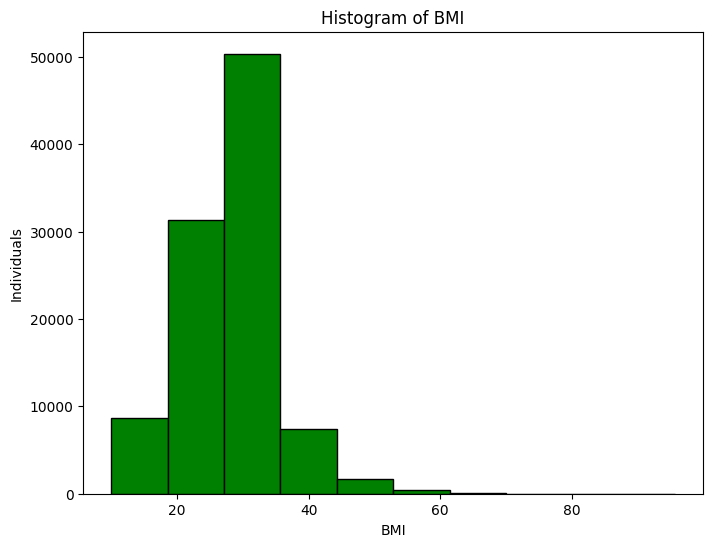

In [22]:
#Display unique values
sorted_unique_values_bmi = df['bmi'].sort_values().unique()
print(sorted_unique_values_bmi)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df['bmi'], bins=10, edgecolor='black', color='green')
plt.xlabel('BMI')
plt.ylabel('Individuals')
plt.title('Histogram of BMI')

#Conclusion
print('\nTakeaway: No issues here. BMI is a float field and all values appear to be numeric. The distribution of BMI appears right skewed.')

[10.01 10.08 10.14 ... 88.76 91.82 95.69]

Takeaway: No issues here. BMI is a float field and all values appear to be numeric. The distribution of BMI appears right skewed.


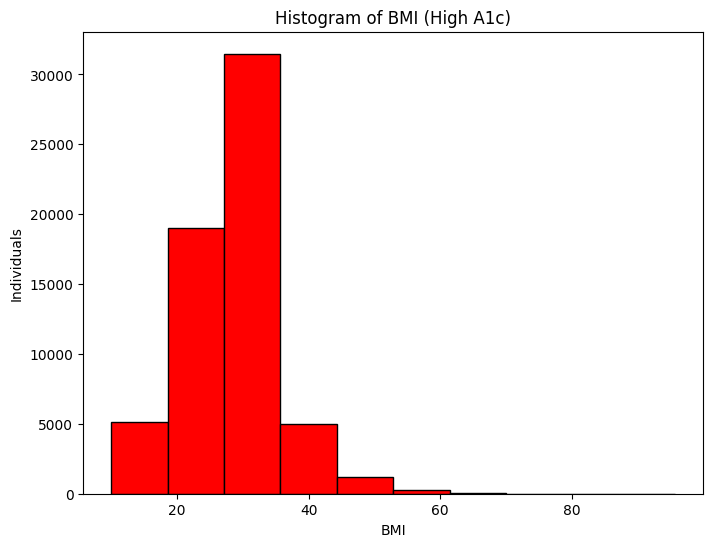

In [23]:
#Display unique values (high A1c only)
sorted_unique_values_bmi = df_test['bmi'].sort_values().unique()
print(sorted_unique_values_bmi)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df_test['bmi'], bins=10, edgecolor='black', color='red')
plt.xlabel('BMI')
plt.ylabel('Individuals')
plt.title('Histogram of BMI (High A1c)')

#Conclusion
print('\nTakeaway: No issues here. BMI is a float field and all values appear to be numeric. The distribution of BMI appears right skewed.')

[10.01 10.08 10.14 ... 88.76 91.82 95.69]

Takeaway: No issues here. BMI is a float field and all values appear to be numeric. The distribution of BMI appears right skewed.


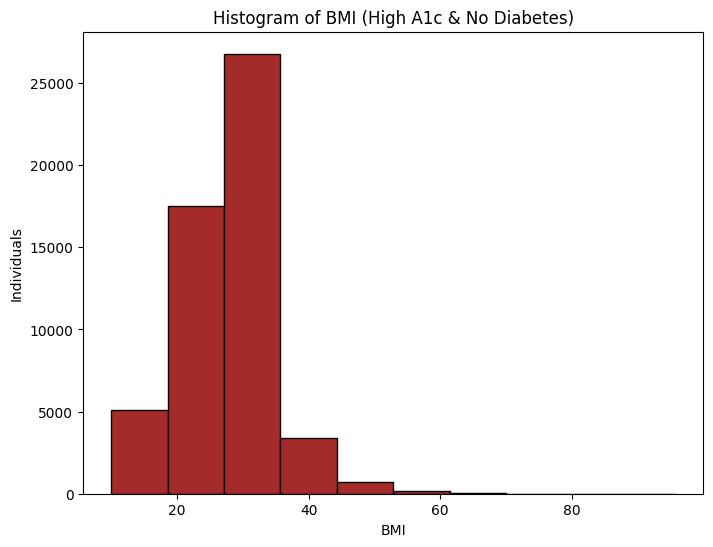

In [24]:
#Display unique values (high A1c and no diabetes only)
sorted_unique_values_bmi = df_no_diabetes['bmi'].sort_values().unique()
print(sorted_unique_values_bmi)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df_no_diabetes['bmi'], bins=10, edgecolor='black', color='brown')
plt.xlabel('BMI')
plt.ylabel('Individuals')
plt.title('Histogram of BMI (High A1c & No Diabetes)')

#Conclusion
print('\nTakeaway: No issues here. BMI is a float field and all values appear to be numeric. The distribution of BMI appears right skewed.')

#### HbA1c Level

[3.5 4.  4.5 4.8 5.  5.7 5.8 6.  6.1 6.2 6.5 6.6 6.8 7.  7.5 8.2 8.8 9. ]

Takeaway: No issues here. HbA1c is a float field and all values appear to be numeric


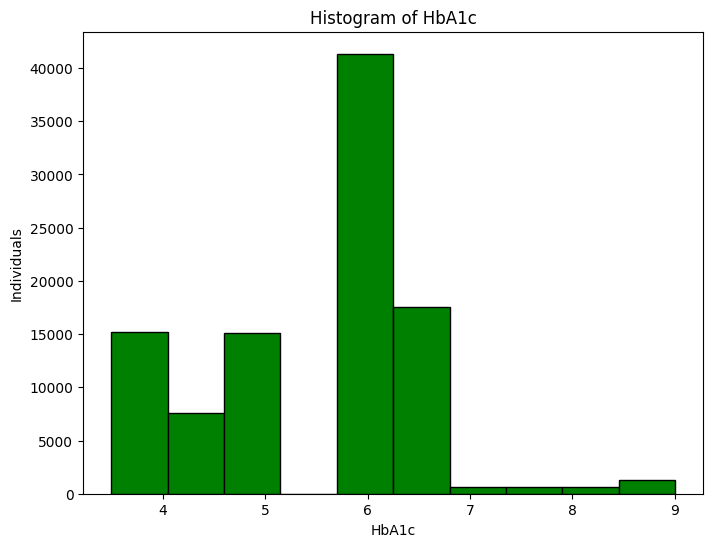

In [25]:
#Display unique values
sorted_unique_values_hba1c = df['HbA1c_level'].sort_values().unique()
print(sorted_unique_values_hba1c)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df['HbA1c_level'], bins=10, edgecolor='black', color='green')
plt.xlabel('HbA1c')
plt.ylabel('Individuals')
plt.title('Histogram of HbA1c')

#Conclusion
print('\nTakeaway: No issues here. HbA1c is a float field and all values appear to be numeric')

[5.7 5.8 6.  6.1 6.2 6.5 6.6 6.8 7.  7.5 8.2 8.8 9. ]

Takeaway: No issues here. HbA1c is a float field and all values appear to be numeric


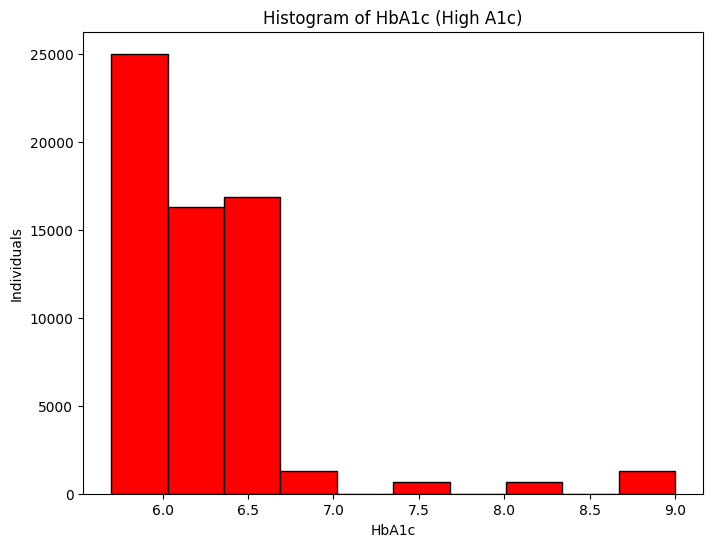

In [26]:
#Display unique values (high A1c)
sorted_unique_values_hba1c = df_test['HbA1c_level'].sort_values().unique()
print(sorted_unique_values_hba1c)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df_test['HbA1c_level'], bins=10, edgecolor='black', color='red')
plt.xlabel('HbA1c')
plt.ylabel('Individuals')
plt.title('Histogram of HbA1c (High A1c)')

#Conclusion
print('\nTakeaway: No issues here. HbA1c is a float field and all values appear to be numeric')

[5.7 5.8 6.  6.1 6.2 6.5 6.6]

Takeaway: No issues here. HbA1c is a float field and all values appear to be numeric


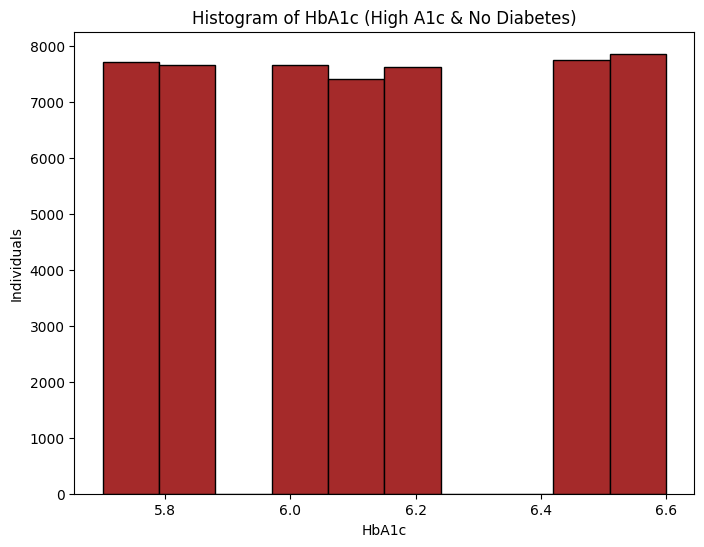

In [27]:
#Display unique values (high A1c and no diabetes only)
sorted_unique_values_hba1c = df_no_diabetes['HbA1c_level'].sort_values().unique()
print(sorted_unique_values_hba1c)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df_no_diabetes['HbA1c_level'], bins=10, edgecolor='black', color='brown')
plt.xlabel('HbA1c')
plt.ylabel('Individuals')
plt.title('Histogram of HbA1c (High A1c & No Diabetes)')

#Conclusion
print('\nTakeaway: No issues here. HbA1c is a float field and all values appear to be numeric')

#### Blood Glucose Level

[ 80  85  90 100 126 130 140 145 155 158 159 160 200 220 240 260 280 300]

Takeaway: No issues here. Blood glucose level is an int field and all values appear to be numeric. The data appears right skewed


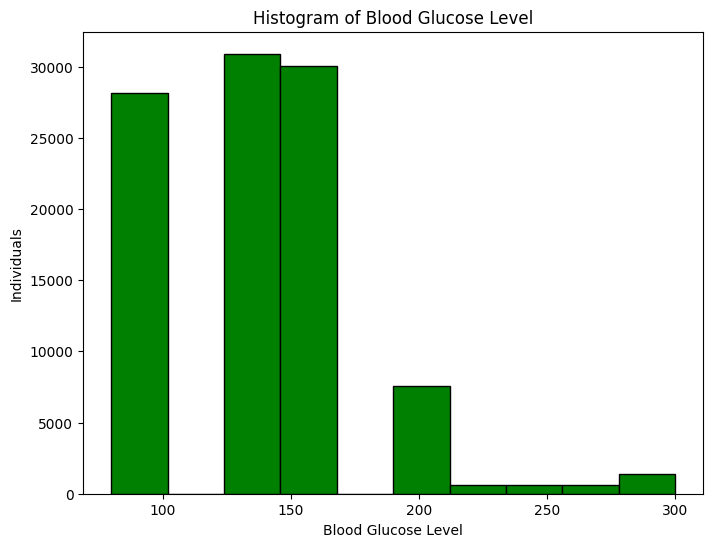

In [28]:
#Display unique values
sorted_unique_values_blood_glucose = df['blood_glucose_level'].sort_values().unique()
print(sorted_unique_values_blood_glucose)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df['blood_glucose_level'], bins=10, edgecolor='black', color='green')
plt.xlabel('Blood Glucose Level')
plt.ylabel('Individuals')
plt.title('Histogram of Blood Glucose Level')

#Conclusion
print('\nTakeaway: No issues here. Blood glucose level is an int field and all values appear to be numeric. The data appears right skewed')

[ 80  85  90 100 126 130 140 145 155 158 159 160 200 220 240 260 280 300]

Takeaway: No issues here. Blood glucose level is an int field and all values appear to be numeric. The data appears right skewed


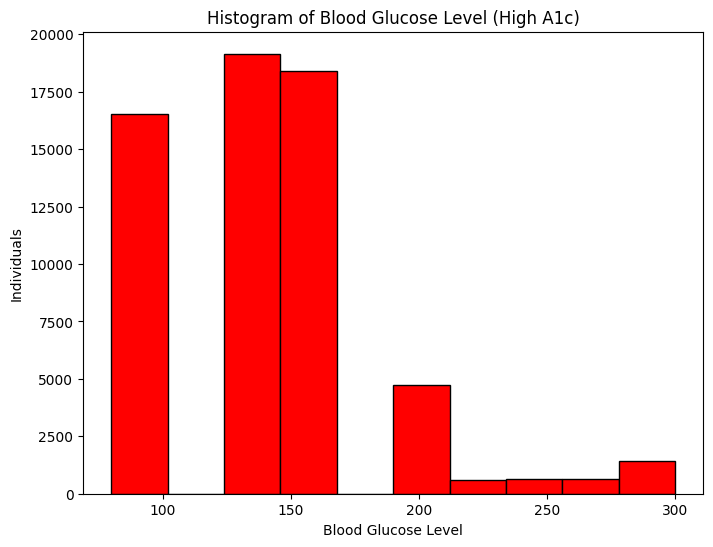

In [29]:
#Display unique values (high A1c)
sorted_unique_values_blood_glucose = df_test['blood_glucose_level'].sort_values().unique()
print(sorted_unique_values_blood_glucose)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df_test['blood_glucose_level'], bins=10, edgecolor='black', color='red')
plt.xlabel('Blood Glucose Level')
plt.ylabel('Individuals')
plt.title('Histogram of Blood Glucose Level (High A1c)')

#Conclusion
print('\nTakeaway: No issues here. Blood glucose level is an int field and all values appear to be numeric. The data appears right skewed')

[ 80  85  90 100 126 130 140 145 155 158 159 160 200]

Takeaway: No issues here. Blood glucose level is an int field and all values appear to be numeric. The data appears right skewed


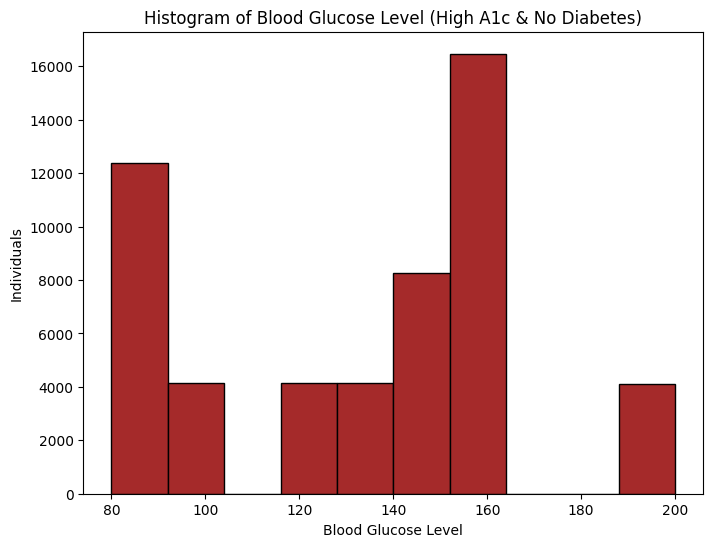

In [30]:
#Display unique values (high A1c and no diabetes only)
sorted_unique_values_blood_glucose = df_no_diabetes['blood_glucose_level'].sort_values().unique()
print(sorted_unique_values_blood_glucose)

#Develop histogram to show distribution of values
plt.figure(figsize=(8,6))
plt.hist(df_no_diabetes['blood_glucose_level'], bins=10, edgecolor='black', color='brown')
plt.xlabel('Blood Glucose Level')
plt.ylabel('Individuals')
plt.title('Histogram of Blood Glucose Level (High A1c & No Diabetes)')

#Conclusion
print('\nTakeaway: No issues here. Blood glucose level is an int field and all values appear to be numeric. The data appears right skewed')

#### Diabetes

[0 1]


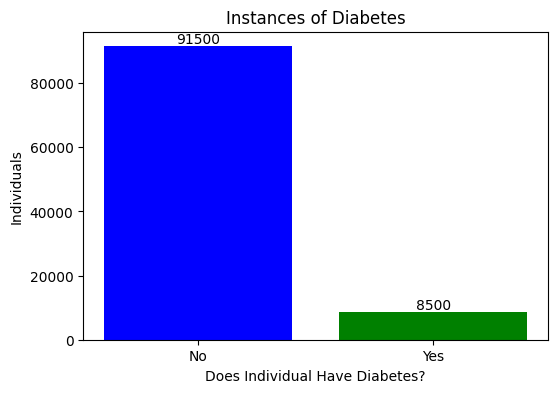


Takeaway: No issues here. Diabetes is a binary field. Per the Kaggle dataset, 0 indicates no diabetes, while 1 indicates diabetes. There are significantly more people without diabetes than those who have it.
This is the final field we will want to test our model on.


In [31]:
#Display unique values
sorted_unique_values_diabetes = df['diabetes'].sort_values().unique()
print(sorted_unique_values_diabetes)

#Develop histogram to show distribution of values
value_counts_diabetes = df['diabetes'].value_counts()
plt.figure(figsize=(6, 4))
bars_heart_diabetes = plt.bar(value_counts_diabetes.index, value_counts_diabetes.values, color=['blue', 'green'])
for bar in bars_heart_diabetes:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Diabetes?')
plt.ylabel('Individuals')
plt.title('Instances of Diabetes')
plt.show()

print("""\nTakeaway: No issues here. Diabetes is a binary field. Per the Kaggle dataset, 0 indicates no diabetes, while 1 indicates diabetes. There are significantly more people without diabetes than those who have it.
This is the final field we will want to test our model on.""")

[0 1]


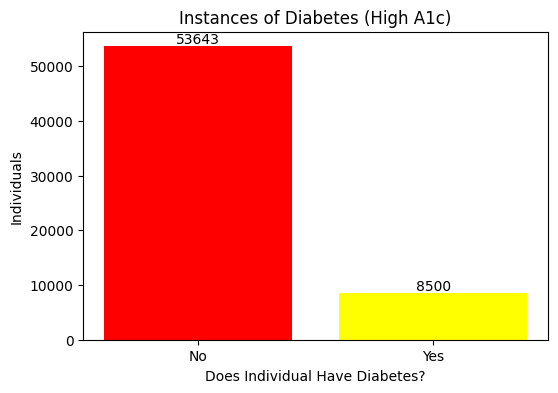


Takeaway: No issues here. Diabetes is a binary field. Per the Kaggle dataset, 0 indicates no diabetes, while 1 indicates diabetes. There are significantly more people without diabetes than those who have it.
This is the final field we will want to test our model on.


In [32]:
#Display unique values (high A1c)
sorted_unique_values_diabetes = df_test['diabetes'].sort_values().unique()
print(sorted_unique_values_diabetes)

#Develop histogram to show distribution of values
value_counts_diabetes = df_test['diabetes'].value_counts()
plt.figure(figsize=(6, 4))
bars_heart_diabetes = plt.bar(value_counts_diabetes.index, value_counts_diabetes.values, color=['red', 'yellow'])
for bar in bars_heart_diabetes:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Diabetes?')
plt.ylabel('Individuals')
plt.title('Instances of Diabetes (High A1c)')
plt.show()

print("""\nTakeaway: No issues here. Diabetes is a binary field. Per the Kaggle dataset, 0 indicates no diabetes, while 1 indicates diabetes. There are significantly more people without diabetes than those who have it.
This is the final field we will want to test our model on.""")

[0]


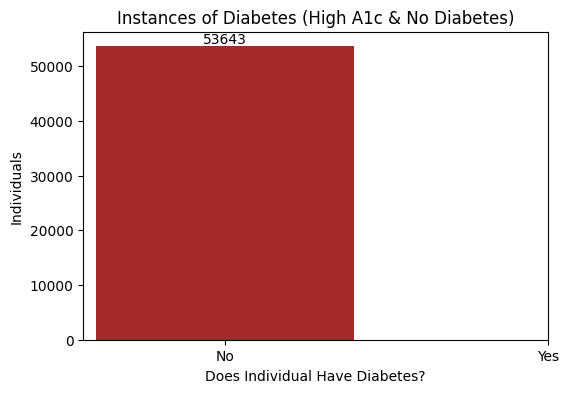


Takeaway: No issues here. Diabetes is a binary field. Per the Kaggle dataset, 0 indicates no diabetes, while 1 indicates diabetes. There are significantly more people without diabetes than those who have it.
This is the final field we will want to test our model on.


In [33]:
#Display unique values (high A1c and no diabetes only)
sorted_unique_values_diabetes = df_no_diabetes['diabetes'].sort_values().unique()
print(sorted_unique_values_diabetes)

#Develop histogram to show distribution of values
value_counts_diabetes = df_no_diabetes['diabetes'].value_counts()
plt.figure(figsize=(6, 4))
bars_heart_diabetes = plt.bar(value_counts_diabetes.index, value_counts_diabetes.values, color=['brown', 'black'])
for bar in bars_heart_diabetes:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Does Individual Have Diabetes?')
plt.ylabel('Individuals')
plt.title('Instances of Diabetes (High A1c & No Diabetes)')
plt.show()

print("""\nTakeaway: No issues here. Diabetes is a binary field. Per the Kaggle dataset, 0 indicates no diabetes, while 1 indicates diabetes. There are significantly more people without diabetes than those who have it.
This is the final field we will want to test our model on.""")